
# Effects of Padding, Stride, ReLU, and MaxPooling

This notebook demonstrates how 2D convolutions work without building a full CNN.

What you'll see:
- Create a synthetic grayscale image (white square on black background)
- Apply hand-crafted filters with `nn.Conv2d` for edge detection
- Effects of kernel size, stride, and padding
- ReLU activation and MaxPooling


In [1]:
# import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def show(img, title=None, cmap='gray'):
    plt.imshow(img, cmap=cmap, vmin=0, vmax=1)
    if title: plt.title(title)

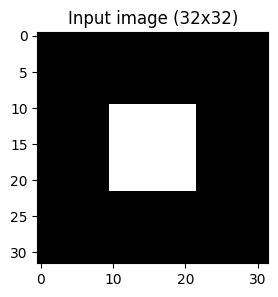

In [2]:

# Create a 32x32 grayscale image with a centered white square
H = W = 32
img = torch.zeros((1, 1, H, W), dtype=torch.float32)  # (N=1, C=1, H, W)
# white square from (10:22, 10:22)
img[:, :, 10:22, 10:22] = 1.0

plt.figure(figsize=(3,3))
show(img.squeeze().numpy(), title='Input image (32x32)')


Now we demonstrate the effects of different stride and padding settings in convolutional layers. Note that `padding=0` means no padding, while `padding='same'` adds padding to preserve the input size. In case of a 5x5 kernel, this adds 2 pixels of padding on each side, so it is equivalent to `padding=2`.

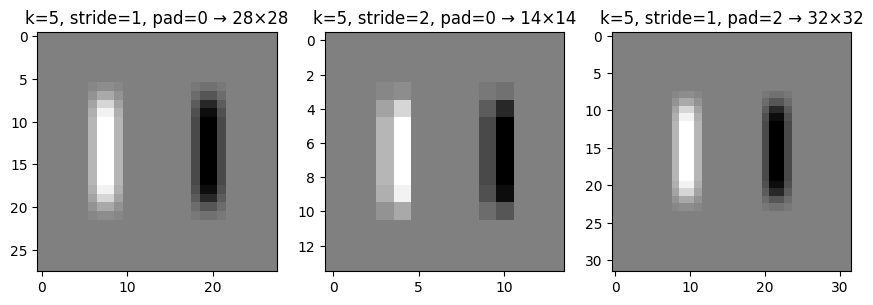

In [3]:
# Define a single Conv2d (1 input channel -> 1 output channel), 3x3 kernel
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)

# Demonstrate stride and padding
conv_stride1 = nn.Conv2d(1, 1, kernel_size=5, stride=1, padding=0, bias=False)
conv_stride2 = nn.Conv2d(1, 1, kernel_size=5, stride=2, padding=0, bias=False)
conv_pad2    = nn.Conv2d(1, 1, kernel_size=5, stride=1, padding='same', bias=False)

# Use the same 5x5 sobel kernel for all three
sobel5x = torch.tensor([
    [-5., -4., 0., 4., 5.],
    [-8., -10., 0., 10., 8.],
    [-10., -20., 0., 20., 10.],
    [-8., -10., 0., 10., 8.],
    [-5., -4., 0., 4., 5.]
], dtype=torch.float32)

# reshape for Conv2d weight (out_channels, in_channels, h, w)
sobel5x = sobel5x.view(1, 1, 5, 5)

with torch.no_grad():
    conv_stride1.weight.copy_(sobel5x)
    conv_stride2.weight.copy_(sobel5x)
    conv_pad2.weight.copy_(sobel5x)

y_s1 = conv_stride1(img).detach().squeeze().numpy()
y_s2 = conv_stride2(img).detach().squeeze().numpy()
y_p2 = conv_pad2(img).detach().squeeze().numpy()

y_s1 = (y_s1 - y_s1.min()) / (y_s1.max() - y_s1.min())  # normalize to [0,1] for better visualization
y_s2 = (y_s2 - y_s2.min()) / (y_s2.max() - y_s2.min())  
y_p2 = (y_p2 - y_p2.min()) / (y_p2.max() - y_p2.min())  

plt.figure(figsize=(10.5,3.5))
plt.subplot(1,3,1); show(y_s1, title=f'k=5, stride=1, pad=0 → {y_s1.shape[0]}×{y_s1.shape[1]}')
plt.subplot(1,3,2); show(y_s2, title=f'k=5, stride=2, pad=0 → {y_s2.shape[0]}×{y_s2.shape[1]}')
plt.subplot(1,3,3); show(y_p2, title=f'k=5, stride=1, pad=2 → {y_p2.shape[0]}×{y_p2.shape[1]}')
plt.show()

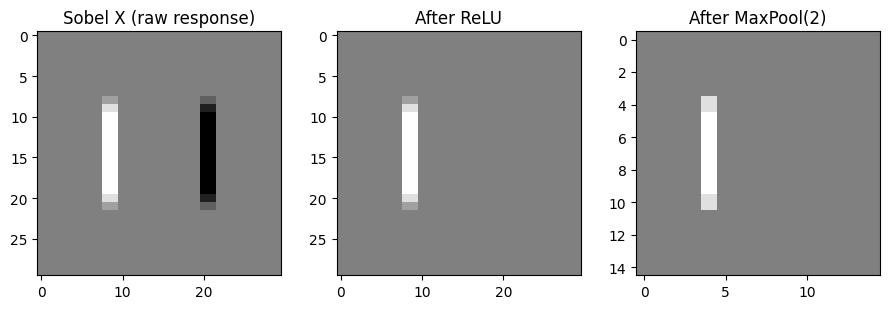

In [ ]:

# ReLU and MaxPool
relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2, stride=2)

# Recompute Sobel X feature map 
sobelx = torch.tensor([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]).view(1,1,3,3)
conv_sobelx = nn.Conv2d(1,1,kernel_size=3,bias=False)
with torch.no_grad():
    conv_sobelx.weight.copy_(sobelx)

feat = conv_sobelx(img) # raw feature map
feat_relu = relu(feat) # after non-linearity
feat_pool = pool(feat_relu) # downsample

max_abs = feat.abs().max() # normalize for better visualization
feat = 0.5 + 0.5 * (feat / max_abs)
feat_relu = 0.5 + 0.5 * (feat_relu / max_abs) 
feat_pool = 0.5 + 0.5 * (feat_pool / max_abs)

feat = feat.detach().squeeze().numpy() 
feat_relu = feat_relu.detach().squeeze().numpy()
feat_pool = feat_pool.detach().squeeze().numpy()

plt.figure(figsize=(9,3))
plt.subplot(1,3,1); show(feat, title='Sobel X (raw response)')
plt.subplot(1,3,2); show(feat_relu, title='After ReLU')
plt.subplot(1,3,3); show(feat_pool, title='After MaxPool(2)')
plt.tight_layout(); plt.show()



## Summary

- Convolution slides a kernel across the image to produce a feature map.
- Kernels can detect different features, for example edges/orientations (e.g., Sobel filters).
- Stride controls the step size; Padding preserves spatial size.
- ReLU keeps positive responses, introducing non-linearity.
- MaxPool downsamples by keeping local maxima, making features more spatially robust.
